VAMOS A CREAR UN MODELO CON KNN QUE NOS PERMITA DETERMINAR PUNTOS CALIENTES. LA IDEA ES QUE DENTRO DE ESOS PUNTOS CALIENTES SE ENCUENTRA CIERTA DENSIDAD DE RESTAURANTES. DENTRO DE ESOS PUNTOS, VAMOS A PODER DETERMINAR EL PORCENTAJE DE EXITO QUE TIENE EL LUGAR, ESTO ES PONDERAR EL PUNTAJE EN BASE A LA INVERSA DE LA DISTANCIA DE SUS VECINOS MAS CERCANOS.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Apliquemos KNN, que me prediga las puntuaciones del restaurant en el punto elegido, utilizando una ponderacion 
# para que los vecinos mas cercanos tengan mayor peso (podria ser la inversa de la distancia).

In [2]:
# Cargar los datos desde un archivo CSV
ruta = r'C:\Users\franc\OneDrive\Escritorio\Henry\Cursado Henry\PF\ML\restaurantes csv\restaurantes_2020.csv'
data = pd.read_csv(ruta)

# Seleccionar las columnas necesarias
selected_data = data[['latitud', 'longitud', 'puntuacion_yelp']]

# Dividir los datos en características (X) y objetivo (y)
X = selected_data[['latitud', 'longitud']]
y = selected_data['puntuacion_yelp']

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configurar el modelo KNN con ponderación por distancia
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance')

# Entrenar el modelo
knn_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = knn_model.predict(X_test)

# Calcular el error cuadrático medio (MSE)
mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse}")
#print(f"RMSE: {rmse}")

# Función para predecir el puntaje basado en latitud y longitud
def predecir_puntaje(latitud, longitud):
    nuevo_dato = pd.DataFrame([[latitud, longitud]], columns=['latitud', 'longitud'])
    puntaje_predicho = knn_model.predict(nuevo_dato)
    return puntaje_predicho[0]

# Ejemplo de uso
latitud_ejemplo = 28.017764
longitud_ejemplo = -82.451033
puntaje = predecir_puntaje(latitud_ejemplo, longitud_ejemplo)
print(f"Puntaje predicho para las coordenadas ({latitud_ejemplo}, {longitud_ejemplo}): {puntaje}")


Error cuadrático medio (MSE): 0.42749107929601843
Puntaje predicho para las coordenadas (28.017764, -82.451033): 3.9557343851308326


In [5]:
# Ejemplo de uso
latitud_ejemplo = 28.2
longitud_ejemplo = -82.6
puntaje = predecir_puntaje(latitud_ejemplo, longitud_ejemplo)
print(f"Puntaje predicho para las coordenadas ({latitud_ejemplo}, {longitud_ejemplo}): {puntaje}")

Puntaje predicho para las coordenadas (28.2, -82.6): 3.635216233689148


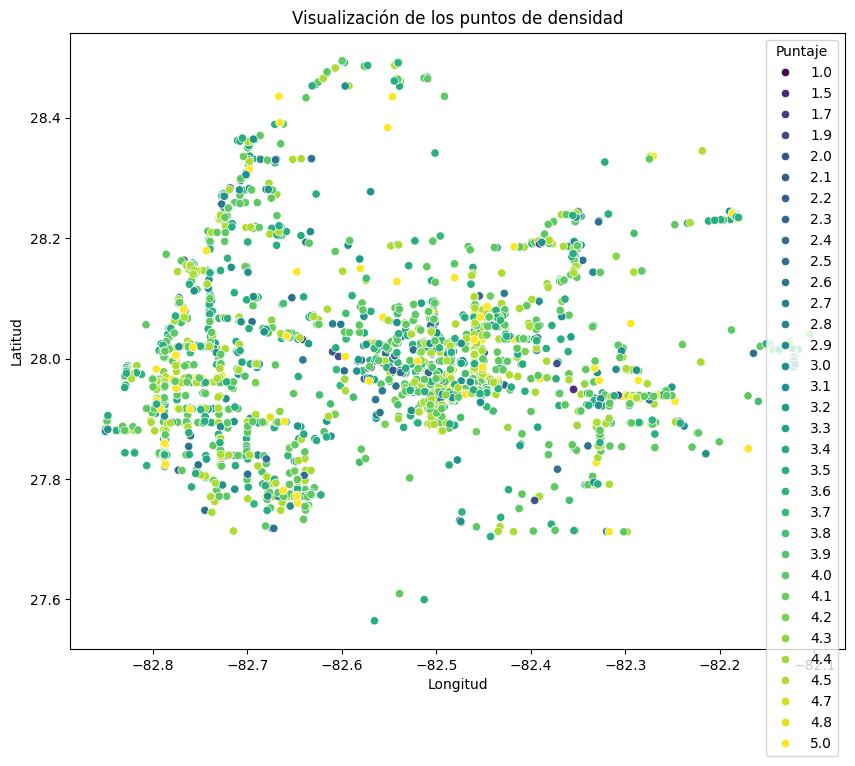

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficar los datos reales y predicciones
plt.figure(figsize=(10, 8))

# Datos de entrenamiento (reales)
sns.scatterplot(
    x=X_train['longitud'], 
    y=X_train['latitud'], 
    hue=y_train, 
    palette="viridis",
    legend='full'
)

# Datos de prueba (predicciones)
# sns.scatterplot(
#     x=X_test['longitud'], 
#     y=X_test['latitud'], 
#     hue=y_pred, 
#     palette="coolwarm",
#     marker="X",
#     legend=False # Evita conflictos de leyendas
# )

# Configurar la gráfica
#plt.title("Visualización de los datos y predicciones KNN")
plt.title("Visualización de los puntos de densidad")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(title="Puntaje")
plt.show()
